# Wheel Strategy Backtest — NVDA (2020–2024)

This notebook walks through the full Wheel Strategy backtest step-by-step:

1. **Load Data** — Stock prices, option chain (5M rows), treasury zero curve
2. **EDA** — Explore each dataset, check for quality issues, understand distributions
3. **Visualize Inputs** — Stock price history, option volume/delta landscape, yield curve
4. **Run Wheel Strategy** — State machine: sell CSPs → get assigned → sell CCs → repeat
5. **Run Buy-and-Hold Benchmark** — Simple comparison
6. **Analyze & Compare** — Performance metrics, trade stats, equity curves side-by-side

---
## 1. Setup & Configuration

In [116]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

# Paths
RAW_DIR = 'data/raw'
STOCK_FILE = os.path.join(RAW_DIR, 'nvda_option_prices.csv')
OPTIONS_FILE = os.path.join(RAW_DIR, 'nvda_option_prices_greeks.csv')
ZERO_CURVE_FILE = os.path.join(RAW_DIR, 'zero_curve.csv')
SP500_FILE = os.path.join(RAW_DIR, 'daily_sp500.csv')

# Strategy parameters
INITIAL_CAPITAL = 100_000
TARGET_DELTA = 0.30
TARGET_DTE = 30 # Date To Expiry
DTE_TOLERANCE = 5
DELTA_TOLERANCE = 0.05
COMMISSION_PER_CONTRACT = 0.65
SHARES_PER_CONTRACT = 100
FALLBACK_RISK_FREE_RATE = 0.015

print('Setup complete.')


Setup complete.


---
## 2. Load Data

### 2a. Stock Prices

WRDS OptionMetrics daily stock data for NVDA. The `cfadj` column is the cumulative adjustment factor — when it jumps, a stock split occurred.

**Split-adjustment approach:** We keep **raw prices** for the backtest (they match raw option strikes in the WRDS data and preserve realistic capital requirements). We create **split-adjusted prices** (`adj_close`) for charts and EDA so the price series is continuous.

`adj_close = close * cfadj / cfadj_final` — maps all prices to the post-all-splits basis.

In [117]:
stock_df = pd.read_csv(STOCK_FILE, parse_dates=['date'], dtype={'secid': 'int32', 'cfadj': 'float64'})
stock_df.sort_values('date', inplace=True)
stock_df.set_index('date', inplace=True)

# Detect splits from cfadj changes
splits = []
cfadj_vals = stock_df['cfadj'].values
for i in range(1, len(cfadj_vals)):
    if cfadj_vals[i] != cfadj_vals[i-1] and cfadj_vals[i-1] != 0:
        ratio = round(cfadj_vals[i] / cfadj_vals[i-1])
        splits.append({
            'date': stock_df.index[i],
            'ratio': ratio,
            'cfadj_before': cfadj_vals[i-1],
            'cfadj_after': cfadj_vals[i],
        })

# Create split-adjusted prices for visualization & EDA
# Formula: adj_price = raw_price * (cfadj / cfadj_final)
# Maps all prices to post-all-splits basis (continuous, no jumps)
cfadj_final = stock_df['cfadj'].iloc[-1]
for col in ['open', 'high', 'low', 'close']:
    stock_df[f'adj_{col}'] = stock_df[col] * stock_df['cfadj'] / cfadj_final

print(f'Stock data: {len(stock_df)} trading days')
print(f'Date range: {stock_df.index[0].date()} to {stock_df.index[-1].date()}')
print(f'\nSplits detected:')
for s in splits:
    print(f"  {s['date'].date()} — {s['ratio']}:1 split (cfadj {s['cfadj_before']} → {s['cfadj_after']})")

print(f'\nRaw prices (used in backtest — match raw option strikes):')
print(f"  Start: ${stock_df['close'].iloc[0]:.2f}  End: ${stock_df['close'].iloc[-1]:.2f}")
print(f'\nSplit-adjusted prices (used in charts — continuous, no jumps):')
print(f"  Start: ${stock_df['adj_close'].iloc[0]:.2f}  End: ${stock_df['adj_close'].iloc[-1]:.2f}")

stock_df.head()

Stock data: 1258 trading days
Date range: 2020-01-02 to 2024-12-31

Splits detected:
  2021-07-20 — 4:1 split (cfadj 12.0 → 48.0)
  2024-06-10 — 10:1 split (cfadj 48.0 → 480.0)

Raw prices (used in backtest — match raw option strikes):
  Start: $239.91  End: $134.29

Split-adjusted prices (used in charts — continuous, no jumps):
  Start: $6.00  End: $134.29


,secid,low,high,open,close,cfadj,adj_open,adj_high,adj_low,adj_close
date,,,,,,,,,,
2020-01-02,108321,236.720,239.91,238.75,239.91,12.0,5.96875,5.99775,5.918000,5.99775
2020-01-03,108321,234.100,237.83,235.10,236.07,12.0,5.87750,5.94575,5.852500,5.90175
2020-01-06,108321,231.270,237.27,232.32,237.06,12.0,5.80800,5.93175,5.781750,5.92650
2020-01-07,108321,236.390,241.77,238.20,239.93,12.0,5.95500,6.04425,5.909750,5.99825
2020-01-08,108321,238.149,242.04,239.76,240.38,12.0,5.99400,6.05100,5.953725,6.00950


In [118]:
stock_df.describe()

,secid,low,high,open,close,cfadj,adj_open,adj_high,adj_low,adj_close
count,1258.0,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,108321.0,356.667362,370.212022,363.589853,363.835040,85.631161,38.475758,39.240131,37.696596,38.471401
std,0.0,214.979631,222.066601,218.839502,218.946814,141.655438,38.289945,39.117703,37.484143,38.228571
min,108321.0,90.690000,103.410000,92.060000,98.910000,12.000000,5.002375,5.248500,4.517017,4.910000
25%,108321.0,182.210000,192.072300,187.255000,187.865000,12.000000,13.631500,13.843799,13.364125,13.608688
50%,108321.0,280.530000,290.157200,285.152500,286.355000,48.000000,21.206750,21.777000,20.849500,21.261500
75%,108321.0,494.622500,515.189900,506.215000,505.035000,48.000000,45.770750,46.223250,44.988250,45.646250
max,108321.0,1183.200000,1255.870000,1240.480000,1224.400000,480.000000,149.350000,195.950000,146.260000,148.880000


### 2b. Option Chain (~5M rows)

WRDS OptionMetrics Greeks data. Key transformations:
- `strike_price / 1000` — WRDS stores strikes multiplied by 1000
- `dte` — days to expiration computed from `exdate - date`
- `mid_price` — midpoint of bid/ask
- Drop rows with null delta or zero bid/offer (unusable)

In [119]:
dtype_map = {
    'cp_flag': 'category', 'strike_price': 'float32',
    'best_bid': 'float32', 'best_offer': 'float32',
    'volume': 'float32', 'open_interest': 'float32',
    'impl_volatility': 'float32', 'delta': 'float32',
    'gamma': 'float32', 'vega': 'float32', 'theta': 'float32',
}
cols = ['date', 'exdate', 'cp_flag', 'strike_price', 'best_bid', 'best_offer',
        'volume', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta']

print('Loading option chain (~5M rows, may take 30-60s) ...')
options_raw = pd.read_csv(OPTIONS_FILE, usecols=cols, dtype=dtype_map, parse_dates=['date', 'exdate'])
print(f'Raw rows: {len(options_raw):,}')

# Transform
options_raw['strike_price'] = options_raw['strike_price'] / 1000.0
options_raw['dte'] = (options_raw['exdate'] - options_raw['date']).dt.days
options_raw['mid_price'] = (options_raw['best_bid'] + options_raw['best_offer']) / 2.0

# Clean
mask = options_raw['delta'].notna() & (options_raw['best_bid'] > 0) & (options_raw['best_offer'] > 0)
options_df = options_raw[mask].copy()
dropped = len(options_raw) - len(options_df)

print(f'After cleaning: {len(options_df):,} rows (dropped {dropped:,})')
print(f'Date range: {options_df["date"].min().date()} to {options_df["date"].max().date()}')

# Free memory
del options_raw

Loading option chain (~5M rows, may take 30-60s) ...
Raw rows: 5,018,160
After cleaning: 4,366,927 rows (dropped 651,233)
Date range: 2020-01-02 to 2024-12-31


In [120]:
options_df.head(10)

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,dte,mid_price
30,2020-01-02,2020-01-03,C,235.0,4.95,5.10,1850.0,2481.0,0.269097,0.930336,0.039604,1.681338,-86.055946,1,5.025
31,2020-01-02,2020-01-03,C,237.5,2.86,2.90,5067.0,2303.0,0.267835,0.767321,0.090858,3.835289,-190.497101,1,2.880
32,2020-01-02,2020-01-03,C,240.0,1.30,1.35,9226.0,4731.0,0.272275,0.493583,0.116625,5.009460,-250.704407,1,1.325
33,2020-01-02,2020-01-03,C,242.5,0.53,0.54,4535.0,2237.0,0.294030,0.246085,0.085335,3.955920,-213.258698,1,0.535
34,2020-01-02,2020-01-03,C,245.0,0.19,0.20,3010.0,3345.0,0.315598,0.103872,0.045532,2.267271,-130.911499,1,0.195
35,2020-01-02,2020-01-03,C,247.5,0.09,0.11,303.0,1036.0,0.364063,0.052329,0.023403,1.343200,-89.469276,1,0.100
36,2020-01-02,2020-01-03,C,250.0,0.05,0.07,357.0,1729.0,0.415447,0.029914,0.013023,0.853698,-64.798828,1,0.060
37,2020-01-02,2020-01-03,C,252.5,0.02,0.05,142.0,3183.0,0.458121,0.017012,0.007340,0.530440,-44.400261,1,0.035
38,2020-01-02,2020-01-03,C,255.0,0.01,0.05,123.0,359.0,0.521493,0.013203,0.005186,0.427208,-40.641911,1,0.030
72,2020-01-02,2020-01-03,P,222.5,0.02,0.03,279.0,1716.0,0.617991,-0.009451,0.003274,0.319066,-35.944550,1,0.025


### 2c. Zero Curve (Risk-Free Rate)

30-day zero-coupon rate from WRDS. Data starts 2020-03-16, so we backfill early 2020 with a fallback rate (~1.5%).

In [121]:
zero_raw = pd.read_csv(ZERO_CURVE_FILE, parse_dates=['date'])
zero_raw = zero_raw[zero_raw['days'] == 30].copy()
zero_raw['rate'] = zero_raw['rate'] / 100.0  # % to decimal
zero_raw.set_index('date', inplace=True)
zero_raw = zero_raw[['rate']].sort_index()

# Reindex to full business-day range
full_range = pd.bdate_range(start='2020-01-02', end='2024-12-31')
zero_curve = zero_raw.reindex(full_range)
zero_curve.index.name = 'date'
zero_curve.ffill(inplace=True)
zero_curve.fillna(FALLBACK_RISK_FREE_RATE, inplace=True)

print(f'Zero curve: {len(zero_curve)} business days')
print(f'Rate range: {zero_curve["rate"].min():.4f} to {zero_curve["rate"].max():.4f}')
zero_curve.head()

Zero curve: 1304 business days
Rate range: 0.0007 to 0.0547


,rate
date,
2020-01-02,0.015
2020-01-03,0.015
2020-01-06,0.015
2020-01-07,0.015
2020-01-08,0.015


---
## 3. Exploratory Data Analysis

### 3a. Stock Price Overview

In [122]:
print('=== Stock Price Summary (Split-Adjusted) ===')
print(f"Start price:  ${stock_df['adj_close'].iloc[0]:.2f}")
print(f"End price:    ${stock_df['adj_close'].iloc[-1]:.2f}")
print(f"Min price:    ${stock_df['adj_close'].min():.2f}")
print(f"Max price:    ${stock_df['adj_close'].max():.2f}")

# Daily returns computed from adjusted prices (no fake split drops)
stock_df['daily_return'] = stock_df['adj_close'].pct_change()
print(f"\nAvg daily return:  {stock_df['daily_return'].mean():.4%}")
print(f"Daily vol (std):   {stock_df['daily_return'].std():.4%}")
print(f"Ann. volatility:   {stock_df['daily_return'].std() * np.sqrt(252):.1%}")
print(f"Worst day:         {stock_df['daily_return'].min():.2%}")
print(f"Best day:          {stock_df['daily_return'].max():.2%}")

=== Stock Price Summary (Split-Adjusted) ===
Start price:  $6.00
End price:    $134.29
Min price:    $4.91
Max price:    $148.88

Avg daily return:  0.3047%
Daily vol (std):   3.3940%
Ann. volatility:   53.9%
Worst day:         -18.45%
Best day:          24.37%


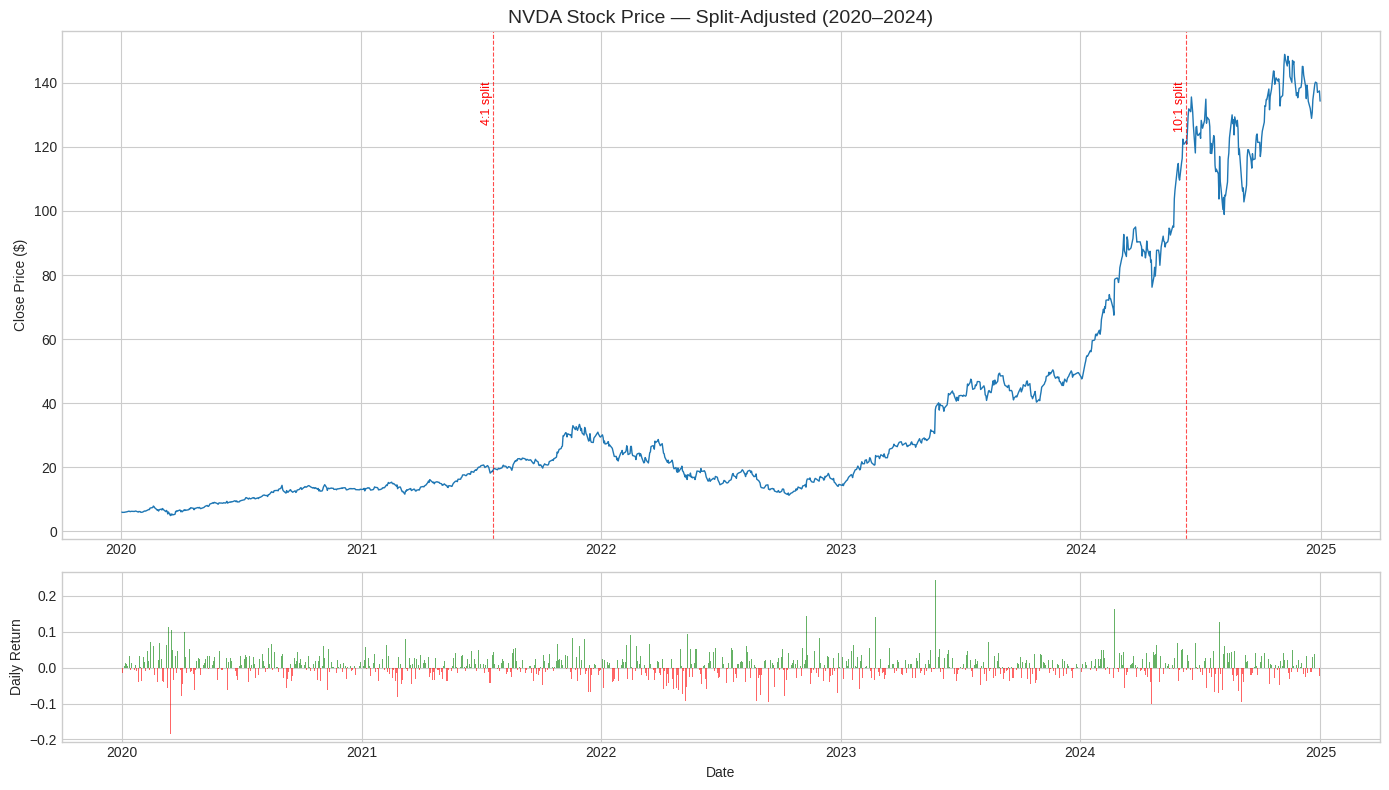

In [123]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Price chart (split-adjusted)
ax = axes[0]
ax.plot(stock_df.index, stock_df['adj_close'], linewidth=1, color='tab:blue')
for s in splits:
    ax.axvline(s['date'], color='red', linestyle='--', alpha=0.7, linewidth=0.8)
    ax.text(s['date'], ax.get_ylim()[1] * 0.9, f"{s['ratio']}:1 split",
            fontsize=9, rotation=90, va='top', ha='right', color='red')
ax.set_title('NVDA Stock Price — Split-Adjusted (2020–2024)', fontsize=14)
ax.set_ylabel('Close Price ($)')

# Daily returns
ax = axes[1]
ax.bar(stock_df.index, stock_df['daily_return'].fillna(0), width=1,
       color=np.where(stock_df['daily_return'].fillna(0) >= 0, 'green', 'red'), alpha=0.6)
ax.set_ylabel('Daily Return')
ax.set_xlabel('Date')

fig.tight_layout()
plt.show()

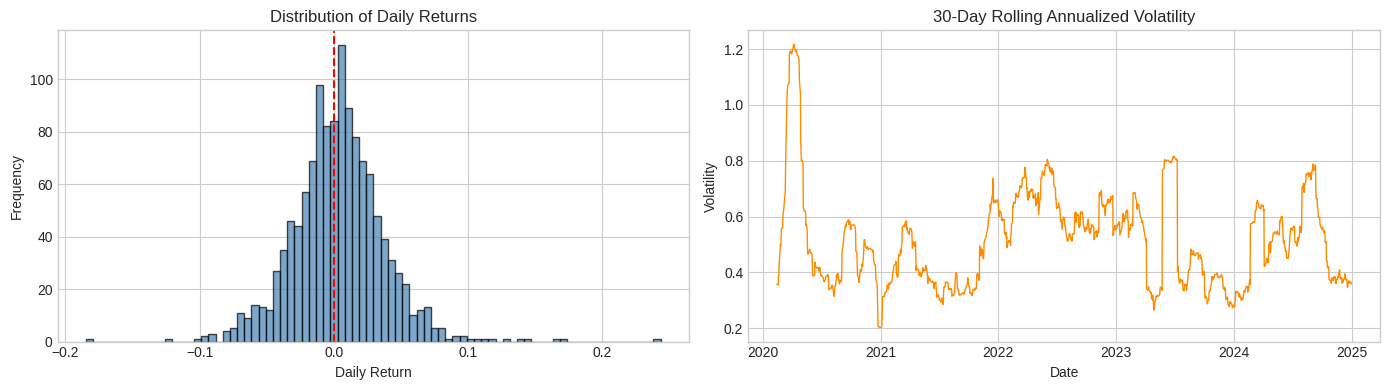

In [124]:
# Daily return distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(stock_df['daily_return'].dropna(), bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution of Daily Returns')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

# Rolling 30-day realized volatility
rolling_vol = stock_df['daily_return'].rolling(30).std() * np.sqrt(252)
axes[1].plot(rolling_vol.index, rolling_vol, linewidth=1, color='darkorange')
axes[1].set_title('30-Day Rolling Annualized Volatility')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

fig.tight_layout()
plt.show()

### 3b. Option Chain EDA

In [125]:
print('=== Option Chain Summary ===')
print(f'Total rows:      {len(options_df):,}')
print(f'Unique dates:    {options_df["date"].nunique()}')
print(f'Unique expiries: {options_df["exdate"].nunique()}')
print(f'\nBy type:')
print(options_df['cp_flag'].value_counts())
print(f'\nStrike range: ${options_df["strike_price"].min():.2f} – ${options_df["strike_price"].max():.2f}')
print(f'DTE range:    {options_df["dte"].min()} – {options_df["dte"].max()} days')
print(f'\nDelta range:  {options_df["delta"].min():.4f} to {options_df["delta"].max():.4f}')
print(f'IV range:     {options_df["impl_volatility"].min():.4f} to {options_df["impl_volatility"].max():.4f}')
print(f'\nNull counts:')
print(options_df[['delta', 'gamma', 'vega', 'theta', 'impl_volatility']].isnull().sum())

=== Option Chain Summary ===
Total rows:      4,366,927
Unique dates:    1258
Unique expiries: 281

By type:
cp_flag
C    2255441
P    2111486
Name: count, dtype: int64

Strike range: $0.50 – $2500.00
DTE range:    1 – 1078 days

Delta range:  -1.0000 to 1.0000
IV range:     0.0344 to 8.9966

Null counts:
delta              0
gamma              0
vega               0
theta              0
impl_volatility    0
dtype: int64


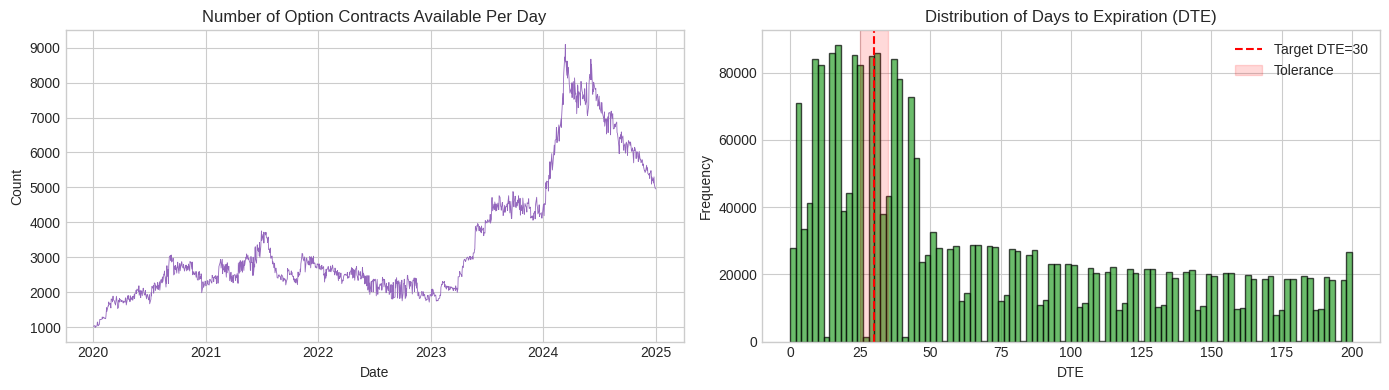

In [126]:
# Options available per day
opts_per_day = options_df.groupby('date').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(opts_per_day.index, opts_per_day.values, linewidth=0.6, color='tab:purple')
axes[0].set_title('Number of Option Contracts Available Per Day')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Date')

# DTE distribution
axes[1].hist(options_df['dte'], bins=100, edgecolor='black', alpha=0.7, color='tab:green', range=(0, 200))
axes[1].axvline(TARGET_DTE, color='red', linestyle='--', label=f'Target DTE={TARGET_DTE}')
axes[1].axvspan(TARGET_DTE - DTE_TOLERANCE, TARGET_DTE + DTE_TOLERANCE, alpha=0.15, color='red', label='Tolerance')
axes[1].set_title('Distribution of Days to Expiration (DTE)')
axes[1].set_xlabel('DTE')
axes[1].set_ylabel('Frequency')
axes[1].legend()

fig.tight_layout()
plt.show()

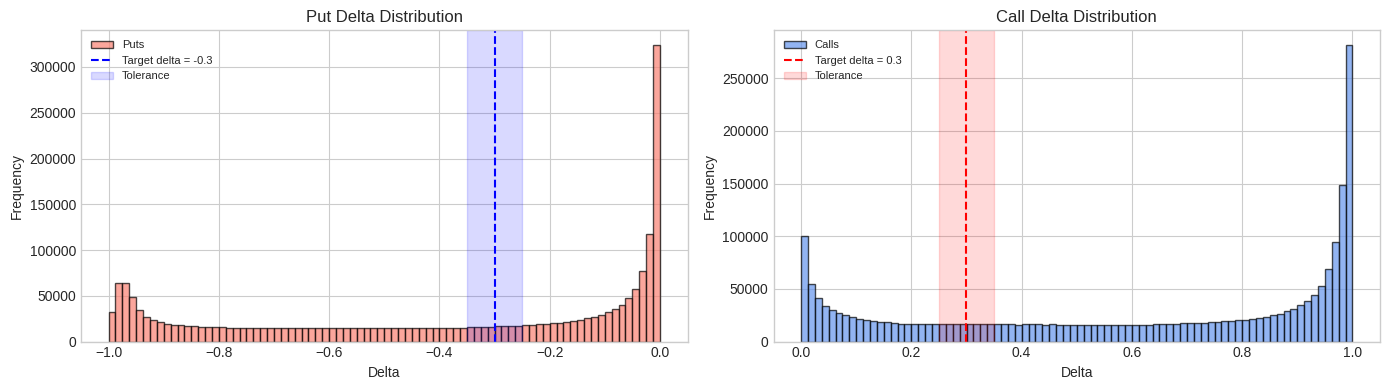

In [127]:
# Delta distribution by type
puts = options_df[options_df['cp_flag'] == 'P']
calls = options_df[options_df['cp_flag'] == 'C']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(puts['delta'], bins=80, edgecolor='black', alpha=0.7, color='salmon', label='Puts')
axes[0].axvline(-TARGET_DELTA, color='blue', linestyle='--', linewidth=1.5, label=f'Target delta = {-TARGET_DELTA}')
axes[0].axvspan(-TARGET_DELTA - DELTA_TOLERANCE, -TARGET_DELTA + DELTA_TOLERANCE,
                alpha=0.15, color='blue', label='Tolerance')
axes[0].set_title('Put Delta Distribution')
axes[0].set_xlabel('Delta')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)

axes[1].hist(calls['delta'], bins=80, edgecolor='black', alpha=0.7, color='cornflowerblue', label='Calls')
axes[1].axvline(TARGET_DELTA, color='red', linestyle='--', linewidth=1.5, label=f'Target delta = {TARGET_DELTA}')
axes[1].axvspan(TARGET_DELTA - DELTA_TOLERANCE, TARGET_DELTA + DELTA_TOLERANCE,
                alpha=0.15, color='red', label='Tolerance')
axes[1].set_title('Call Delta Distribution')
axes[1].set_xlabel('Delta')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

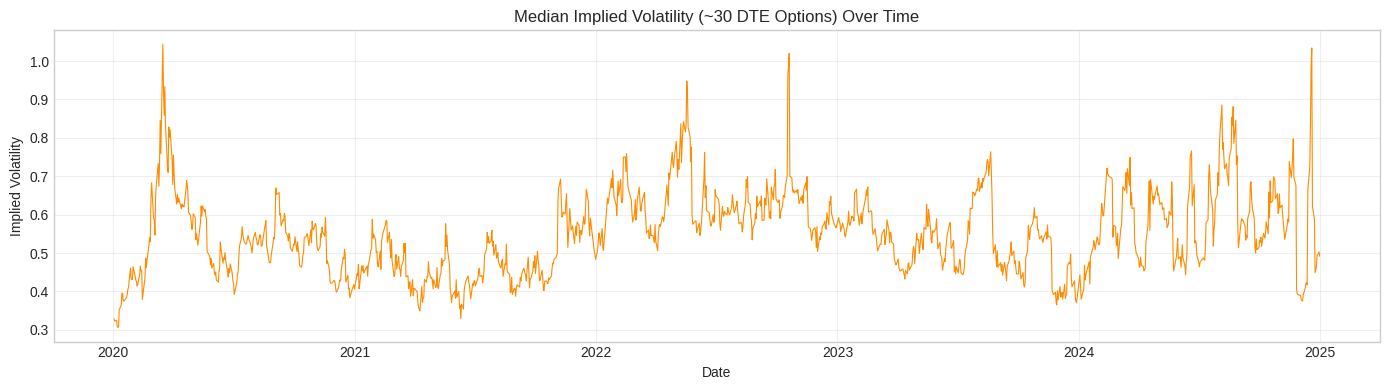

In [128]:
# Implied volatility over time (median IV of ~30 DTE options)
near_target = options_df[(options_df['dte'] >= 25) & (options_df['dte'] <= 35)].copy()
iv_by_day = near_target.groupby('date')['impl_volatility'].median()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(iv_by_day.index, iv_by_day.values, linewidth=0.8, color='darkorange')
ax.set_title('Median Implied Volatility (~30 DTE Options) Over Time')
ax.set_ylabel('Implied Volatility')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 3c. Treasury Zero Curve (Risk-Free Rate)

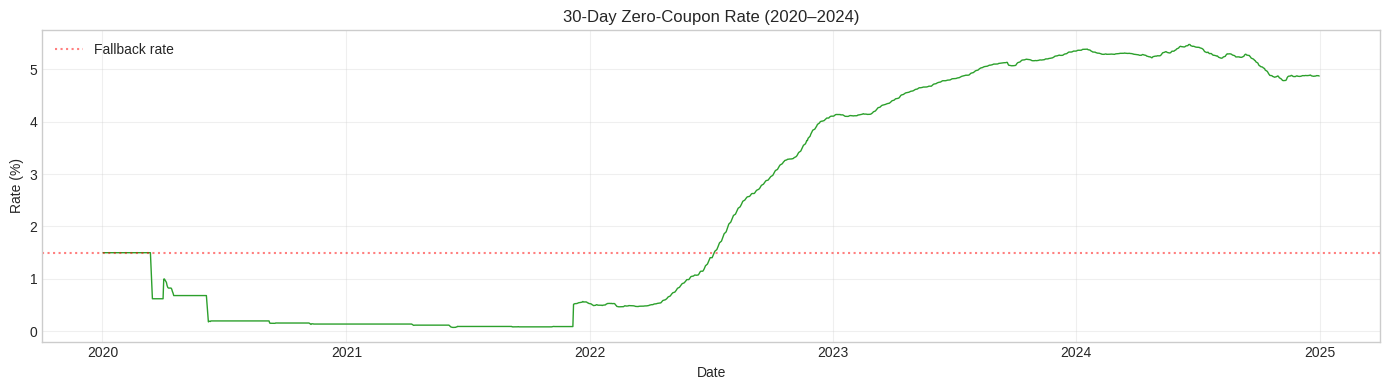

Note: Data starts 2020-03-16. Earlier dates backfilled with 1.5% fallback.


In [129]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(zero_curve.index, zero_curve['rate'] * 100, linewidth=1, color='tab:green')
ax.set_title('30-Day Zero-Coupon Rate (2020–2024)')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Date')
ax.axhline(y=FALLBACK_RISK_FREE_RATE * 100, color='red', linestyle=':', alpha=0.5, label='Fallback rate')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f'Note: Data starts 2020-03-16. Earlier dates backfilled with {FALLBACK_RISK_FREE_RATE:.1%} fallback.')

---
## 4. Filter Options for Strategy

The Wheel strategy needs to find one option per trade:
- **Puts:** delta in [-0.35, -0.25], DTE in [25, 35]
- **Calls:** delta in [0.25, 0.35], DTE in [25, 35]

Let's see how many candidates we have per day.

In [130]:
# Filter to strategy-relevant options
dte_mask = (options_df['dte'] >= TARGET_DTE - DTE_TOLERANCE) & (options_df['dte'] <= TARGET_DTE + DTE_TOLERANCE)

put_delta_mask = (options_df['delta'] >= -TARGET_DELTA - DELTA_TOLERANCE) & (options_df['delta'] <= -TARGET_DELTA + DELTA_TOLERANCE)
call_delta_mask = (options_df['delta'] >= TARGET_DELTA - DELTA_TOLERANCE) & (options_df['delta'] <= TARGET_DELTA + DELTA_TOLERANCE)

put_candidates = options_df[dte_mask & put_delta_mask & (options_df['cp_flag'] == 'P')]
call_candidates = options_df[dte_mask & call_delta_mask & (options_df['cp_flag'] == 'C')]

print(f'Strategy-eligible puts:  {len(put_candidates):,} rows across {put_candidates["date"].nunique()} days')
print(f'Strategy-eligible calls: {len(call_candidates):,} rows across {call_candidates["date"].nunique()} days')

Strategy-eligible puts:  7,545 rows across 1258 days
Strategy-eligible calls: 6,698 rows across 1258 days


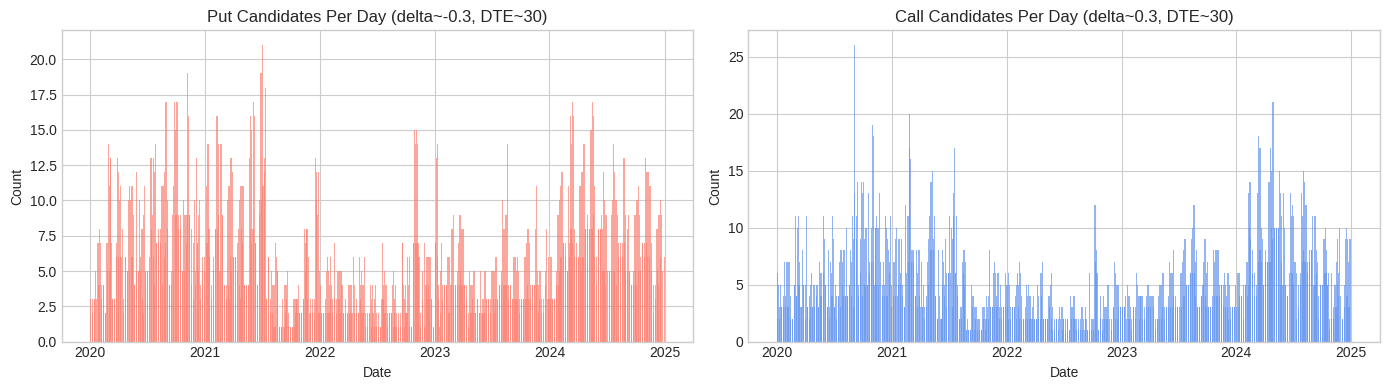

In [131]:
# Candidates per day
put_per_day = put_candidates.groupby('date').size()
call_per_day = call_candidates.groupby('date').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(put_per_day.index, put_per_day.values, width=2, color='salmon', alpha=0.7)
axes[0].set_title(f'Put Candidates Per Day (delta~{-TARGET_DELTA}, DTE~{TARGET_DTE})')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Date')

axes[1].bar(call_per_day.index, call_per_day.values, width=2, color='cornflowerblue', alpha=0.7)
axes[1].set_title(f'Call Candidates Per Day (delta~{TARGET_DELTA}, DTE~{TARGET_DTE})')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Date')

fig.tight_layout()
plt.show()

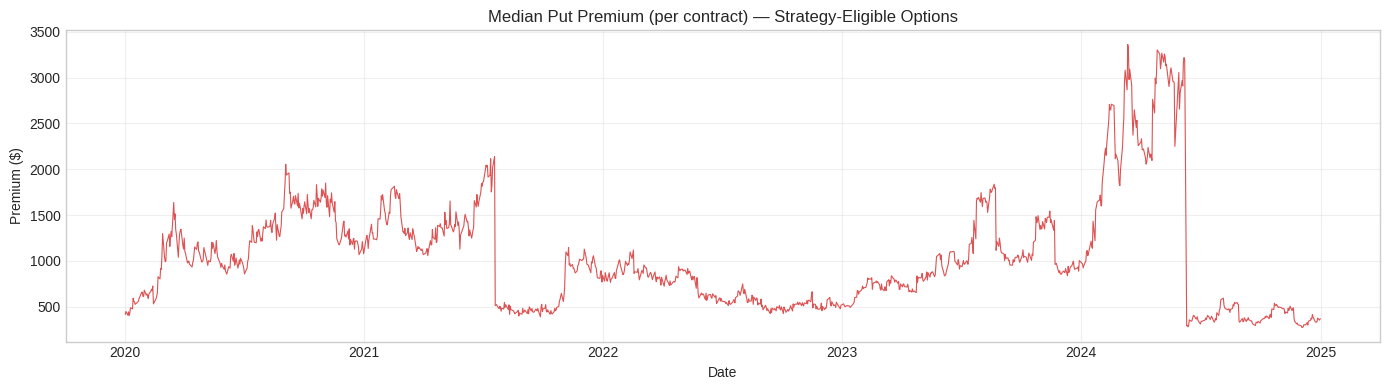

In [132]:
# Premium available for strategy-eligible puts over time
put_premium_by_day = put_candidates.groupby('date')['mid_price'].median() * SHARES_PER_CONTRACT

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(put_premium_by_day.index, put_premium_by_day.values, linewidth=0.8, color='tab:red', alpha=0.8)
ax.set_title('Median Put Premium (per contract) — Strategy-Eligible Options')
ax.set_ylabel('Premium ($)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 5. Build Option Index

Pre-group the option chain by `(date, cp_flag)` for O(1) lookups during the simulation.

In [133]:
option_index = {}
for (date, cp_flag), group in options_df.groupby(['date', 'cp_flag']):
    option_index[(date, cp_flag)] = group

print(f'Option index built: {len(option_index):,} (date, type) groups')

Option index built: 2,516 (date, type) groups


In [134]:
def select_option(option_index, trade_date, cp_flag,
                  target_delta=TARGET_DELTA, target_dte=TARGET_DTE,
                  dte_tolerance=DTE_TOLERANCE, delta_tolerance=DELTA_TOLERANCE):
    """Select best option by delta/DTE match."""
    key = (trade_date, cp_flag)
    if key not in option_index:
        return None

    candidates = option_index[key]
    dte_min, dte_max = target_dte - dte_tolerance, target_dte + dte_tolerance
    candidates = candidates[(candidates['dte'] >= dte_min) & (candidates['dte'] <= dte_max)]
    if candidates.empty:
        return None

    if cp_flag == 'P':
        delta_center = -target_delta
    else:
        delta_center = target_delta
    delta_min = delta_center - delta_tolerance
    delta_max = delta_center + delta_tolerance
    candidates = candidates[(candidates['delta'] >= delta_min) & (candidates['delta'] <= delta_max)]
    if candidates.empty:
        return None

    candidates = candidates.copy()
    candidates['delta_dist'] = (candidates['delta'] - delta_center).abs()
    candidates['dte_dist'] = (candidates['dte'] - target_dte).abs()
    candidates.sort_values(['delta_dist', 'dte_dist'], inplace=True)

    best = candidates.iloc[0]
    return {
        'strike': float(best['strike_price']),
        'exdate': best['exdate'],
        'mid_price': float(best['mid_price']),
        'delta': float(best['delta']),
        'dte': int(best['dte']),
        'impl_volatility': float(best['impl_volatility']) if pd.notna(best['impl_volatility']) else None,
    }

# Quick sanity check on a few dates
sample_dates = [pd.Timestamp('2020-01-15'), pd.Timestamp('2022-06-15'), pd.Timestamp('2024-09-15')]
for d in sample_dates:
    p = select_option(option_index, d, 'P')
    c = select_option(option_index, d, 'C')
    print(f'{d.date()}: Put={p}  Call={c}')

2020-01-15: Put={'strike': 232.5, 'exdate': Timestamp('2020-02-14 00:00:00'), 'mid_price': 5.599999904632568, 'delta': -0.29468101263046265, 'dte': 30, 'impl_volatility': 0.40283799171447754}  Call={'strike': 262.5, 'exdate': Timestamp('2020-02-14 00:00:00'), 'mid_price': 4.425000190734863, 'delta': 0.28659000992774963, 'dte': 30, 'impl_volatility': 0.37087199091911316}
2022-06-15: Put={'strike': 155.0, 'exdate': Timestamp('2022-07-15 00:00:00'), 'mid_price': 6.699999809265137, 'delta': -0.32312899827957153, 'dte': 30, 'impl_volatility': 0.609250009059906}  Call={'strike': 180.0, 'exdate': Timestamp('2022-07-15 00:00:00'), 'mid_price': 4.899999618530273, 'delta': 0.3197669982910156, 'dte': 30, 'impl_volatility': 0.5396590232849121}
2024-09-15: Put=None  Call=None


---
## 6. Run Wheel Strategy

The Wheel is a state machine with 4 states:

1. **SELLING_CSP** — Sell a cash-secured put (delta ~0.30)
2. **WAITING_PUT_EXPIRY** — Hold until expiration
3. **SELLING_CC** — If assigned, sell a covered call (delta ~0.30)
4. **WAITING_CALL_EXPIRY** — Hold until expiration

If the call expires ITM, shares are called away and we go back to step 1.

In [135]:
# ── Wheel Strategy State Machine ──────────────────────────────────────────
#
# The Wheel cycles through 4 states:
#   SELLING_CSP          → We have cash, looking to sell a cash-secured put
#   WAITING_PUT_EXPIRY   → Holding a short put, waiting for expiration
#   SELLING_CC           → We own shares (were assigned), selling a covered call
#   WAITING_CALL_EXPIRY  → Holding a short call, waiting for expiration
#
# On each trading day the loop does:
#   1. Check if a stock split happened → adjust shares, cost basis, and
#      the active option's stored strike (which was captured pre-split)
#   2. Accrue T-bill interest on investable cash (cash not reserved as CSP collateral)
#   3. Check if the current option has expired
#   4. If no option is active, sell a new one (CSP or CC depending on state)
#   5. Record the daily portfolio value: cash + shares * stock_close
#
# P&L accounting:
#   A 'trade' in the log is a full CYCLE, not a single leg.
#   - CSP expires worthless → cycle P&L = premium collected (simple)
#   - CSP assigned → CC(s) sold → eventually called away or still holding:
#     cycle P&L = sum of all premiums + (exit_price - put_strike) * 100
#   This avoids double-counting price movement across put and call legs.
#
# Key design decisions:
#   - One contract at a time ($100K capital is sufficient)
#   - Hold to expiration (no early close / rolling)
#   - Premium = mid_price * 100 shares - commission
#   - T-bill accrual uses effective daily rate from annualized zero-curve quote:
#       daily_rate = (1 + annual_rate) ** (1/252) - 1

SELLING_CSP = 'SELLING_CSP'
WAITING_PUT_EXPIRY = 'WAITING_PUT_EXPIRY'
SELLING_CC = 'SELLING_CC'
WAITING_CALL_EXPIRY = 'WAITING_CALL_EXPIRY'


def annual_to_daily_effective(annual_rate, trading_days=252):
    """Convert annualized yield quote (decimal) to effective daily rate."""
    if annual_rate <= -1:
        return 0.0
    return (1.0 + annual_rate) ** (1.0 / trading_days) - 1.0


def run_wheel(stock_df, splits, option_index, zero_curve, initial_capital=INITIAL_CAPITAL):
    """
    Run the Wheel Strategy day-by-day over the full stock price history.

    Parameters
    ----------
    stock_df : DataFrame
        Daily stock prices indexed by date.
    splits : list[dict]
        Split events with {'date', 'ratio'}.
    option_index : dict
        Pre-indexed options by (date, cp_flag).
    zero_curve : DataFrame
        Must contain a 'rate' column (annualized decimal) indexed by date.

    Returns
    -------
    (daily_df, trade_log, skip_stats)
        daily_df  : DataFrame with daily portfolio value, cash, shares, state
        trade_log : list of dicts, one per completed CYCLE (not per leg)
        skip_stats: diagnostics incl. T-bill interest collected
    """
    cash = initial_capital
    shares = 0
    cost_basis = 0.0       # per-share cost basis (set when assigned on a put)
    state = SELLING_CSP
    current_option = None  # dict describing the active short option, or None

    cycle = None  # dict with 'put_entry_date', 'put_strike', 'premiums', 'legs', etc.

    split_lookup = {s['date']: s['ratio'] for s in splits}
    trade_log = []
    daily_records = []

    # Skip counters — help diagnose why trade count may seem low
    skipped_no_candidate = 0      # no option matched delta/DTE filters
    skipped_insufficient_cash = 0 # found option but can't meet collateral
    days_waiting = 0              # holding an active option (not looking to trade)

    # Cash enhancement tracking
    tbill_interest_total = 0.0

    for date in stock_df.index:
        close = stock_df.loc[date, 'close']  # raw (not split-adjusted) price

        # ── Step 1: Handle stock split ───────────────────────────────
        if date in split_lookup:
            ratio = split_lookup[date]
            if shares > 0:
                shares *= ratio        # 100 shares → 400 shares (4:1)
                cost_basis /= ratio    # $750/share → $187.50/share
            if current_option is not None:
                # Our stored strike was captured pre-split; adjust to match
                # the now post-split stock prices
                current_option['strike'] /= ratio
            if cycle is not None:
                # Adjust the original put strike too (used for final P&L calc)
                cycle['put_strike'] /= ratio

        # ── Step 2: Accrue T-bill interest on investable cash ────────
        # If a CSP is open, reserve strike*100 as collateral and only invest excess.
        reserved_collateral = 0.0
        if current_option is not None and current_option.get('type') == 'P':
            reserved_collateral = current_option['strike'] * SHARES_PER_CONTRACT

        investable_cash = max(cash - reserved_collateral, 0.0)
        annual_rate = float(zero_curve.loc[date, 'rate']) if date in zero_curve.index else FALLBACK_RISK_FREE_RATE
        daily_rate = annual_to_daily_effective(annual_rate)
        tbill_interest = investable_cash * daily_rate

        cash += tbill_interest
        tbill_interest_total += tbill_interest

        # ── Step 3: Check if current option has expired ──────────────
        if current_option is not None and date >= current_option['exdate']:
            # Build a leg record for the cycle
            leg = {
                'type': current_option['type'],
                'entry_date': current_option['entry_date'],
                'exit_date': date,
                'strike': current_option['strike'],
                'exdate': current_option['exdate'],
                'delta': current_option['delta'],
                'dte': current_option['dte'],
                'mid_price': current_option['mid_price'],
                'premium': current_option['premium_collected'],
            }

            if state == WAITING_PUT_EXPIRY:
                if close <= current_option['strike']:
                    # PUT ITM → assigned: buy 100 shares at strike
                    cash -= current_option['strike'] * SHARES_PER_CONTRACT
                    shares += SHARES_PER_CONTRACT
                    cost_basis = current_option['strike']
                    leg['outcome'] = 'ASSIGNED'
                    cycle['legs'].append(leg)
                    state = SELLING_CC  # now sell covered calls
                else:
                    # PUT OTM → expired worthless. Cycle is complete.
                    leg['outcome'] = 'EXPIRED_WORTHLESS'
                    cycle['legs'].append(leg)
                    cycle['exit_date'] = date
                    cycle['exit_type'] = 'PUT_EXPIRED'
                    cycle['exit_price'] = None
                    cycle['pnl'] = cycle['total_premiums']  # pure premium profit
                    trade_log.append(cycle)
                    cycle = None
                    state = SELLING_CSP
                current_option = None

            elif state == WAITING_CALL_EXPIRY:
                if close >= current_option['strike']:
                    # CALL ITM → shares called away at strike
                    proceeds = current_option['strike'] * SHARES_PER_CONTRACT
                    cash += proceeds
                    leg['outcome'] = 'CALLED_AWAY'
                    cycle['legs'].append(leg)
                    # Cycle complete: compute true round-trip P&L
                    cycle['exit_date'] = date
                    cycle['exit_type'] = 'CALLED_AWAY'
                    cycle['exit_price'] = current_option['strike']
                    # True P&L = all premiums + (exit - entry) * 100
                    cycle['pnl'] = (cycle['total_premiums']
                                    + (current_option['strike'] - cycle['put_strike'])
                                    * SHARES_PER_CONTRACT)
                    trade_log.append(cycle)
                    cycle = None
                    shares = 0
                    cost_basis = 0.0
                    state = SELLING_CSP
                else:
                    # CALL OTM → expired worthless, keep premium + keep shares
                    leg['outcome'] = 'EXPIRED_WORTHLESS'
                    cycle['legs'].append(leg)
                    state = SELLING_CC  # sell another call
                current_option = None

        # ── Step 4: Sell a new option if we don't have one ───────────
        if current_option is None:
            if state == SELLING_CSP:
                opt = select_option(option_index, date, 'P')
                if opt is None:
                    skipped_no_candidate += 1
                elif cash < opt['strike'] * SHARES_PER_CONTRACT:
                    skipped_insufficient_cash += 1
                else:
                    premium = opt['mid_price'] * SHARES_PER_CONTRACT - COMMISSION_PER_CONTRACT
                    cash += premium
                    current_option = {**opt, 'type': 'P', 'entry_date': date,
                                      'premium_collected': premium}
                    # Start a new cycle
                    cycle = {
                        'entry_date': date,
                        'put_strike': opt['strike'],
                        'total_premiums': premium,
                        'legs': [],
                    }
                    state = WAITING_PUT_EXPIRY

            elif state == SELLING_CC:
                opt = select_option(option_index, date, 'C')
                if opt is None:
                    skipped_no_candidate += 1
                elif shares < SHARES_PER_CONTRACT:
                    pass  # shouldn't happen, but just in case
                else:
                    premium = opt['mid_price'] * SHARES_PER_CONTRACT - COMMISSION_PER_CONTRACT
                    cash += premium
                    current_option = {**opt, 'type': 'C', 'entry_date': date,
                                      'premium_collected': premium}
                    # Add premium to the running cycle total
                    cycle['total_premiums'] += premium
                    state = WAITING_CALL_EXPIRY
        else:
            days_waiting += 1

        # ── Step 5: Record daily portfolio snapshot ──────────────────
        daily_records.append({
            'date': date,
            'total_value': cash + shares * close,
            'cash': cash,
            'shares': shares,
            'stock_close': close,
            'state': state,
            'rf_rate_annual': annual_rate,
            'tbill_interest': tbill_interest,
            'tbill_interest_cum': tbill_interest_total,
            'reserved_collateral': reserved_collateral,
            'investable_cash': investable_cash,
        })

    # If a cycle is still open at the end (e.g. holding shares or waiting),
    # close it at market value for reporting
    if cycle is not None:
        last_close = stock_df.iloc[-1]['close']
        if shares > 0:
            exit_price = last_close
        else:
            exit_price = None
        cycle['exit_date'] = stock_df.index[-1]
        cycle['exit_type'] = 'OPEN_AT_END'
        cycle['exit_price'] = exit_price
        if exit_price is not None:
            cycle['pnl'] = (cycle['total_premiums']
                            + (exit_price - cycle['put_strike']) * SHARES_PER_CONTRACT)
        else:
            cycle['pnl'] = cycle['total_premiums']  # put still pending
        trade_log.append(cycle)

    daily_df = pd.DataFrame(daily_records).set_index('date')
    skip_stats = {
        'skipped_no_candidate': skipped_no_candidate,
        'skipped_insufficient_cash': skipped_insufficient_cash,
        'days_waiting': days_waiting,
        'tbill_interest_total': tbill_interest_total,
    }
    return daily_df, trade_log, skip_stats


wheel_daily, trade_log, skip_stats = run_wheel(stock_df, splits, option_index, zero_curve)

print(f'Cycles completed: {len(trade_log)}')
print(f'Final portfolio value: ${wheel_daily["total_value"].iloc[-1]:,.2f}')
print(f'Total T-bill interest earned: ${skip_stats["tbill_interest_total"]:,.2f}')
print(f'\n--- Day-by-day breakdown ({len(stock_df)} trading days) ---')
print(f'  Days holding active option:  {skip_stats["days_waiting"]}')
print(f'  Days skipped (no candidate): {skip_stats["skipped_no_candidate"]}')
print(f'  Days skipped (low cash):     {skip_stats["skipped_insufficient_cash"]}')
legs_sold = sum(len(c["legs"]) for c in trade_log)
print(f'  Days a new option was sold:  {legs_sold}')
print(f'  Total:                       {skip_stats["days_waiting"] + skip_stats["skipped_no_candidate"] + skip_stats["skipped_insufficient_cash"] + legs_sold}')



Cycles completed: 40
Final portfolio value: $168,988.89
Total T-bill interest earned: $12,798.24

--- Day-by-day breakdown (1258 trading days) ---
  Days holding active option:  1199
  Days skipped (no candidate): 0
  Days skipped (low cash):     0
  Days a new option was sold:  58
  Total:                       1257


### 6a. Trade logs

In [136]:
# Cycle log — each entry is a full put→(optional calls)→exit cycle
cycles_df = pd.DataFrame(trade_log)
print(f'Total cycles: {len(cycles_df)}')
print(f'\nExit type breakdown:')
print(cycles_df['exit_type'].value_counts())

# Count total legs across all cycles
total_legs = sum(len(c['legs']) for c in trade_log)
put_legs = sum(1 for c in trade_log for leg in c['legs'] if leg['type'] == 'P')
call_legs = sum(1 for c in trade_log for leg in c['legs'] if leg['type'] == 'C')
print(f'\nTotal option legs: {total_legs} (puts: {put_legs}, calls: {call_legs})')

# Display summary of each cycle
cycle_summary = cycles_df[['entry_date', 'exit_date', 'put_strike',
                            'exit_type', 'exit_price', 'total_premiums', 'pnl']].copy()
cycle_summary['n_legs'] = [len(c['legs']) for c in trade_log]
cycle_summary

Total cycles: 40

Exit type breakdown:
exit_type
PUT_EXPIRED    32
CALLED_AWAY     7
OPEN_AT_END     1
Name: count, dtype: int64

Total option legs: 58 (puts: 39, calls: 19)


,entry_date,exit_date,put_strike,exit_type,exit_price,total_premiums,pnl,n_legs
0,2020-01-02,2020-01-31,230.0,PUT_EXPIRED,NaN,414.350010,414.350010,1
1,2020-01-31,2020-02-28,222.5,PUT_EXPIRED,NaN,669.349981,669.349981,1
2,2020-02-28,2020-04-03,242.5,PUT_EXPIRED,NaN,1336.850000,1336.850000,1
3,2020-04-03,2020-05-01,225.0,PUT_EXPIRED,NaN,1061.850000,1061.850000,1
4,2020-05-01,2020-06-05,260.0,PUT_EXPIRED,NaN,1181.850076,1181.850076,1
5,2020-06-05,2020-07-02,337.5,PUT_EXPIRED,NaN,801.849962,801.849962,1
6,2020-07-02,2020-07-31,365.0,PUT_EXPIRED,NaN,856.849981,856.849981,1
7,2020-07-31,2020-09-04,395.0,PUT_EXPIRED,NaN,1459.350038,1459.350038,1
8,2020-09-04,2020-10-02,467.5,PUT_EXPIRED,NaN,1876.849962,1876.849962,1
9,2020-10-02,2020-11-06,485.0,PUT_EXPIRED,NaN,1809.350038,1809.350038,1


### 6b. Interactive Payoff Diagram

Step through each trading day with a slider. Shows the **payoff at expiration** of the current short option position:
- **Short Put:** profit is capped at the premium; losses grow as stock falls below strike
- **Short Call:** profit is capped at the premium; losses grow as stock rises above strike
- The red dot marks where the stock is trading that day

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Build list of days that have an active option
active_days = [r for r in wheel_daily.itertuples()
               if r.state in ('WAITING_PUT_EXPIRY', 'WAITING_CALL_EXPIRY')]
print(f'{len(active_days)} days with an active option position')

# Flatten cycle legs into a single DataFrame for lookup
all_legs = []
for c in trade_log:
    for leg in c['legs']:
        all_legs.append(leg)
legs_df = pd.DataFrame(all_legs)
legs_df['entry_date'] = pd.to_datetime(legs_df['entry_date'])
legs_df['exit_date'] = pd.to_datetime(legs_df['exit_date'])

def get_active_leg(date):
    """Find the leg that was active on a given date."""
    mask = (legs_df['entry_date'] <= date) & (legs_df['exit_date'] >= date)
    matches = legs_df[mask]
    if matches.empty:
        return None
    return matches.iloc[-1]

out = widgets.Output()

def update(day_idx):
    row = active_days[day_idx]
    date = row.Index
    stock_price = row.stock_close

    opt = get_active_leg(date)
    if opt is None:
        return

    strike = opt['strike']
    premium = opt['premium']
    opt_type = opt['type']

    margin = strike * 0.4
    prices = np.linspace(strike - margin, strike + margin, 500)

    if opt_type == 'P':
        payoff = np.where(prices >= strike, premium,
                          premium - (strike - prices) * SHARES_PER_CONTRACT)
        label = 'Short Put'
        color = 'salmon'
    else:
        payoff = np.where(prices <= strike, premium,
                          premium - (prices - strike) * SHARES_PER_CONTRACT)
        label = 'Short Call'
        color = 'cornflowerblue'

    breakeven = strike - premium / SHARES_PER_CONTRACT if opt_type == 'P' \
                else strike + premium / SHARES_PER_CONTRACT

    if opt_type == 'P':
        current_pnl = premium if stock_price >= strike \
                      else premium - (strike - stock_price) * SHARES_PER_CONTRACT
    else:
        current_pnl = premium if stock_price <= strike \
                      else premium - (stock_price - strike) * SHARES_PER_CONTRACT

    dte_remaining = (opt['exdate'] - date).days

    with out:
        out.clear_output(wait=True)
        fig2, ax2 = plt.subplots(figsize=(12, 5))
        ax2.plot(prices, payoff, linewidth=2, color=color, label=label)
        ax2.fill_between(prices, payoff, 0, where=(payoff >= 0), alpha=0.15, color='green')
        ax2.fill_between(prices, payoff, 0, where=(payoff < 0), alpha=0.15, color='red')
        ax2.axhline(0, color='black', linewidth=0.5)

        ax2.axvline(strike, color='gray', linestyle='--', alpha=0.6)
        ax2.text(strike, max(payoff) * 0.85, f'Strike ${strike:.2f}',
                 ha='center', fontsize=9, color='gray')

        ax2.axvline(breakeven, color='orange', linestyle=':', alpha=0.7)
        ax2.text(breakeven, min(payoff) * 0.7, f'B/E ${breakeven:.2f}',
                 ha='center', fontsize=9, color='orange')

        ax2.plot(stock_price, current_pnl, 'ro', markersize=10, zorder=5,
                 label=f'Stock ${stock_price:.2f}')
        ax2.annotate(f'${stock_price:.2f}\nP&L: ${current_pnl:,.0f}',
                     xy=(stock_price, current_pnl),
                     xytext=(15, 15), textcoords='offset points',
                     fontsize=9, color='red', fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

        ax2.set_title(f'{date.date()} — {label} | Strike ${strike:.2f} | '
                      f'Premium ${premium:,.0f} | DTE {dte_remaining}d | '
                      f'Delta {opt["delta"]:.2f}', fontsize=12)
        ax2.set_xlabel('Stock Price at Expiration ($)')
        ax2.set_ylabel('P&L ($)')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        fig2.tight_layout()
        plt.show()

slider = widgets.IntSlider(
    value=0, min=0, max=len(active_days) - 1, step=1,
    description='Day:', continuous_update=False,
    layout=widgets.Layout(width='80%'),
)
play = widgets.Play(value=0, min=0, max=len(active_days) - 1, step=1, interval=200)
widgets.jslink((play, 'value'), (slider, 'value'))

def on_change(change):
    update(change['new'])

slider.observe(on_change, names='value')

display(widgets.HBox([play, slider]))
display(out)

# Show initial state
update(0)

1258 days with an active option position


Output()

---
## 7. Run Benchmarks — NVDA Buy-and-Hold & S&P 500

In [138]:
def run_buy_and_hold(stock_df, splits, initial_capital=INITIAL_CAPITAL):
    split_lookup = {s['date']: s['ratio'] for s in splits}

    first_close = stock_df.iloc[0]['close']
    shares = math.floor(initial_capital / first_close)
    cash = initial_capital - shares * first_close

    records = []
    for date in stock_df.index:
        if date in split_lookup:
            shares *= split_lookup[date]
        close = stock_df.loc[date, 'close']
        records.append({'date': date, 'total_value': cash + shares * close})

    return pd.DataFrame(records).set_index('date')

# NVDA Buy-and-Hold
bh_daily = run_buy_and_hold(stock_df, splits)
first_close = stock_df.iloc[0]['close']
shares_bought = math.floor(INITIAL_CAPITAL / first_close)
print(f'NVDA Buy & Hold: {shares_bought} shares @ ${first_close:.2f}')
print(f'Final value: ${bh_daily["total_value"].iloc[-1]:,.2f}')

# S&P 500 Benchmark
sp500_raw = pd.read_csv(SP500_FILE, parse_dates=['DATE'])
sp500_raw.set_index('DATE', inplace=True)
sp500_raw.sort_index(inplace=True)

# Build total value from daily returns (vwretd)
sp500_daily = pd.DataFrame(index=sp500_raw.index)
sp500_daily['total_value'] = INITIAL_CAPITAL * (1 + sp500_raw['vwretd']).cumprod()
sp500_daily.index.name = 'date'

print(f'\nS&P 500 Benchmark:')
print(f'Final value: ${sp500_daily["total_value"].iloc[-1]:,.2f}')
print(f'Date range: {sp500_daily.index[0].date()} to {sp500_daily.index[-1].date()}')

NVDA Buy & Hold: 416 shares @ $239.91
Final value: $2,234,783.04

S&P 500 Benchmark:
Final value: $181,411.50
Date range: 2020-01-02 to 2024-12-31


---
## 8. Performance Comparison

In [139]:
def compute_metrics(daily_df, label='Strategy'):
    values = daily_df['total_value']
    n_years = (values.index[-1] - values.index[0]).days / 365.25
    total_return = values.iloc[-1] / values.iloc[0] - 1
    cagr = (values.iloc[-1] / values.iloc[0]) ** (1 / n_years) - 1
    daily_returns = values.pct_change().dropna()
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = cagr / ann_vol if ann_vol > 0 else 0
    cummax = values.cummax()
    max_dd = ((values - cummax) / cummax).min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    return {
        'Label': label, 'Initial Value': f'${values.iloc[0]:,.0f}',
        'Final Value': f'${values.iloc[-1]:,.0f}',
        'Total Return': f'{total_return:.1%}', 'CAGR': f'{cagr:.1%}',
        'Ann. Volatility': f'{ann_vol:.1%}', 'Sharpe Ratio': f'{sharpe:.2f}',
        'Max Drawdown': f'{max_dd:.1%}', 'Calmar Ratio': f'{calmar:.2f}',
    }

wheel_m = compute_metrics(wheel_daily, 'Wheel Strategy')
bh_m = compute_metrics(bh_daily, 'NVDA Buy & Hold')
sp_m = compute_metrics(sp500_daily, 'S&P 500')

comparison = pd.DataFrame([wheel_m, bh_m, sp_m]).set_index('Label').T
comparison

Label,Wheel Strategy,NVDA Buy & Hold,S&P 500
Initial Value,"$100,420","$100,000","$100,741"
Final Value,"$168,989","$2,234,783","$181,411"
Total Return,68.3%,2134.8%,80.1%
CAGR,11.0%,86.2%,12.5%
Ann. Volatility,9.8%,53.8%,21.1%
Sharpe Ratio,1.12,1.60,0.59
Max Drawdown,-11.2%,-66.3%,-34.7%
Calmar Ratio,0.98,1.30,0.36


In [140]:
# Cycle statistics
cycles_df = pd.DataFrame(trade_log)
total = len(cycles_df)
wins = (cycles_df['pnl'] > 0).sum()

# Count legs by type
all_legs = [leg for c in trade_log for leg in c['legs']]
legs_df = pd.DataFrame(all_legs)
assignments = (legs_df['outcome'] == 'ASSIGNED').sum() if len(legs_df) > 0 else 0
called_away = (cycles_df['exit_type'] == 'CALLED_AWAY').sum()
put_expired = (cycles_df['exit_type'] == 'PUT_EXPIRED').sum()

print('=== Cycle Statistics ===')
print(f'Total cycles:          {total}')
print(f'  Put expired (no assignment): {put_expired}')
print(f'  Assigned then called away:   {called_away}')
print(f'  Open at end:                 {(cycles_df["exit_type"] == "OPEN_AT_END").sum()}')
print(f'Win rate:              {wins/total:.1%}')
print(f'\nTotal option legs:     {len(all_legs)}')
print(f'  Put legs:            {(legs_df["type"] == "P").sum()}')
print(f'  Call legs:           {(legs_df["type"] == "C").sum()}')
print(f'\nAvg cycle premium:     ${cycles_df["total_premiums"].mean():,.2f}')
print(f'Total premium:         ${cycles_df["total_premiums"].sum():,.2f}')
print(f'Avg cycle P&L:         ${cycles_df["pnl"].mean():,.2f}')
print(f'Total P&L:             ${cycles_df["pnl"].sum():,.2f}')

=== Cycle Statistics ===
Total cycles:          40
  Put expired (no assignment): 32
  Assigned then called away:   7
  Open at end:                 1
Win rate:              97.5%

Total option legs:     58
  Put legs:            39
  Call legs:           19

Avg cycle premium:     $1,462.27
Total premium:         $58,490.65
Avg cycle P&L:         $1,404.77
Total P&L:             $56,190.65


---
## 9. Visualizations

### 9a. Equity Curves — Wheel vs Buy-and-Hold

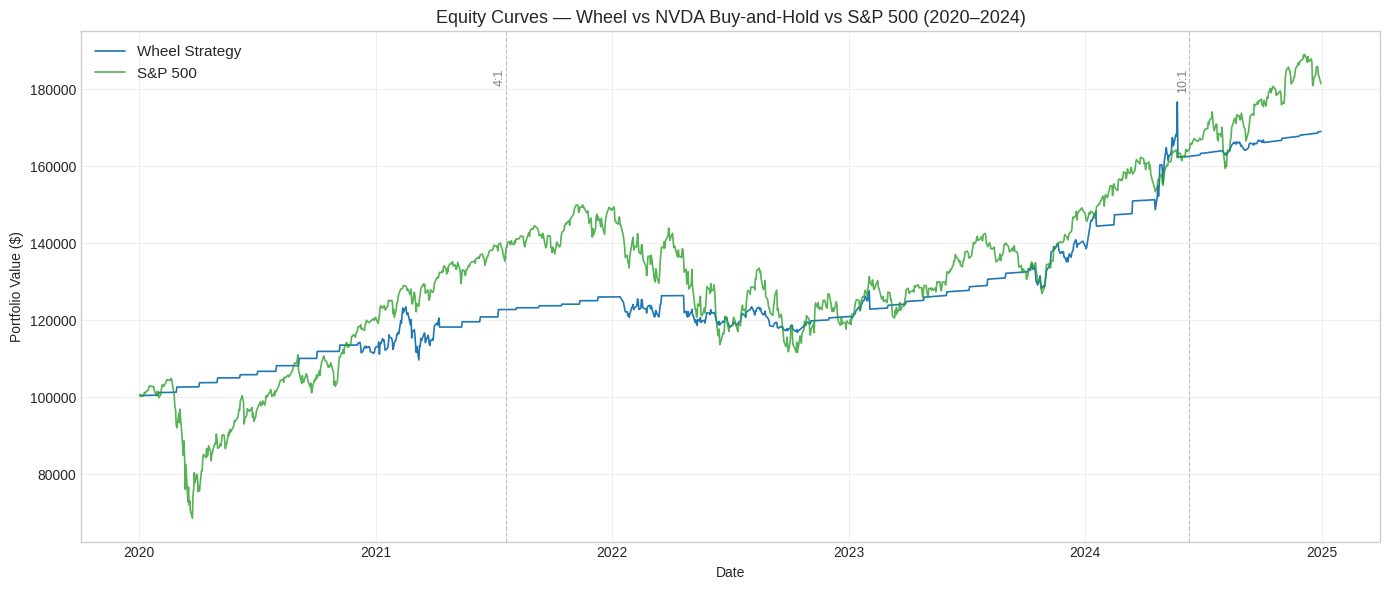

In [141]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(wheel_daily.index, wheel_daily['total_value'], label='Wheel Strategy', linewidth=1.2)
#ax.plot(bh_daily.index, bh_daily['total_value'], label='NVDA Buy & Hold', linewidth=1.2, alpha=0.8)
ax.plot(sp500_daily.index, sp500_daily['total_value'], label='S&P 500', linewidth=1.2, alpha=0.8, color='tab:green')

for s in splits:
    ax.axvline(s['date'], color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text(s['date'], ax.get_ylim()[1] * 0.95, f"{s['ratio']}:1",
            fontsize=9, rotation=90, va='top', ha='right', color='gray')

ax.set_title('Equity Curves — Wheel vs NVDA Buy-and-Hold vs S&P 500 (2020–2024)', fontsize=13)
ax.set_ylabel('Portfolio Value ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

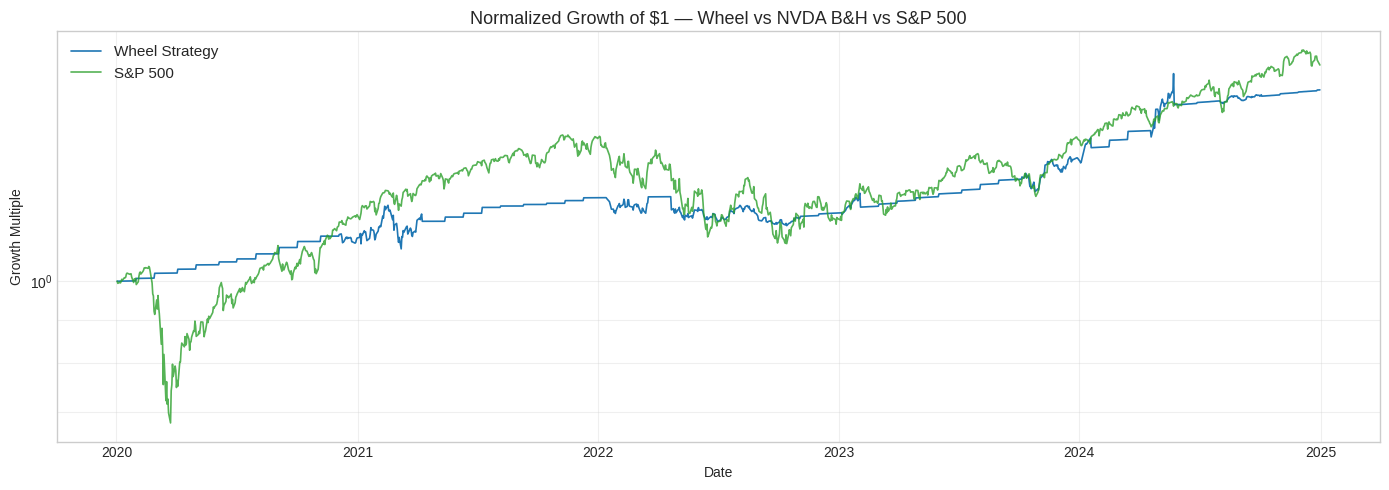

In [142]:
# Normalized to $1 for easier comparison of growth trajectories
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wheel_daily.index, wheel_daily['total_value'] / wheel_daily['total_value'].iloc[0],
        label='Wheel Strategy', linewidth=1.2)
# ax.plot(bh_daily.index, bh_daily['total_value'] / bh_daily['total_value'].iloc[0],
#         label='NVDA Buy & Hold', linewidth=1.2, alpha=0.8)
ax.plot(sp500_daily.index, sp500_daily['total_value'] / sp500_daily['total_value'].iloc[0],
        label='S&P 500', linewidth=1.2, alpha=0.8, color='tab:green')

ax.set_title('Normalized Growth of $1 — Wheel vs NVDA B&H vs S&P 500', fontsize=13)
ax.set_ylabel('Growth Multiple')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()

### 9b. Drawdowns

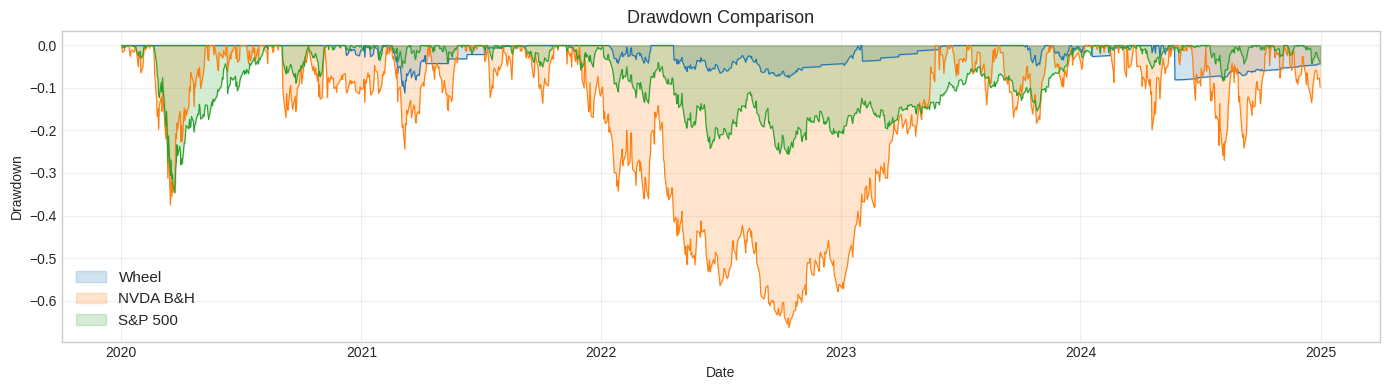

In [143]:
fig, ax = plt.subplots(figsize=(14, 4))

for label, df, color in [('Wheel', wheel_daily, 'tab:blue'),
                          ('NVDA B&H', bh_daily, 'tab:orange'),
                          ('S&P 500', sp500_daily, 'tab:green')]:
    values = df['total_value']
    dd = (values - values.cummax()) / values.cummax()
    ax.fill_between(dd.index, dd.values, alpha=0.2, color=color, label=label)
    ax.plot(dd.index, dd.values, linewidth=0.8, color=color)

ax.set_title('Drawdown Comparison', fontsize=13)
ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 9c. Trade Scatter — Premium by Outcome

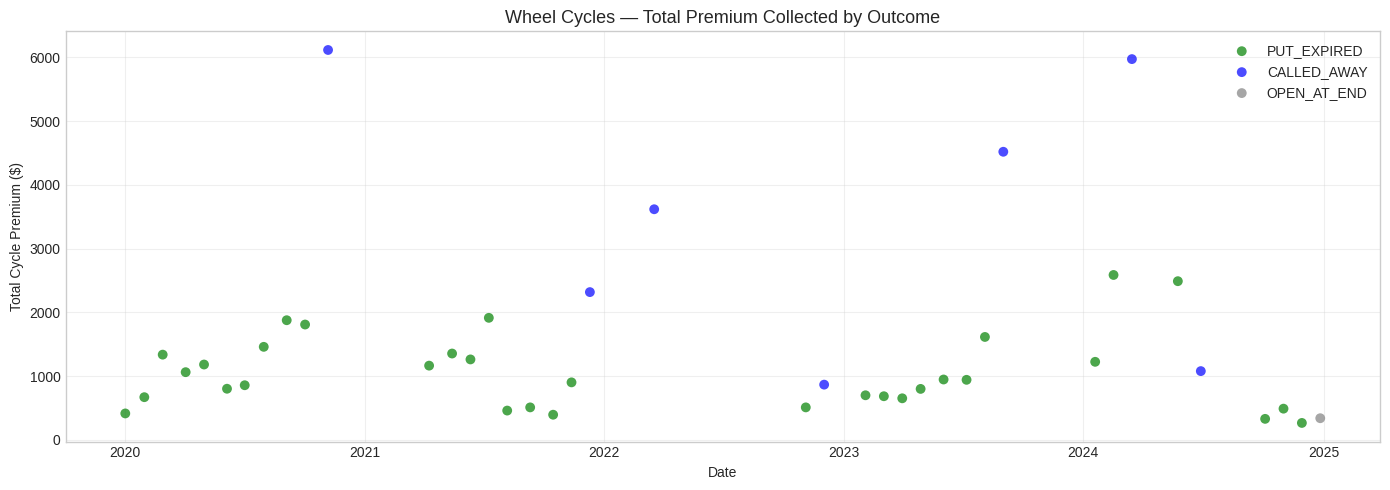

In [144]:
cycles_df = pd.DataFrame(trade_log)

color_map = {'PUT_EXPIRED': 'green', 'CALLED_AWAY': 'blue', 'OPEN_AT_END': 'gray'}

fig, ax = plt.subplots(figsize=(14, 5))
for exit_type, color in color_map.items():
    subset = cycles_df[cycles_df['exit_type'] == exit_type]
    if not subset.empty:
        ax.scatter(subset['entry_date'], subset['total_premiums'],
                   c=color, label=exit_type, alpha=0.7, s=50, edgecolors='none')

ax.set_title('Wheel Cycles — Total Premium Collected by Outcome', fontsize=13)
ax.set_ylabel('Total Cycle Premium ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 9d. Trade P&L Distribution

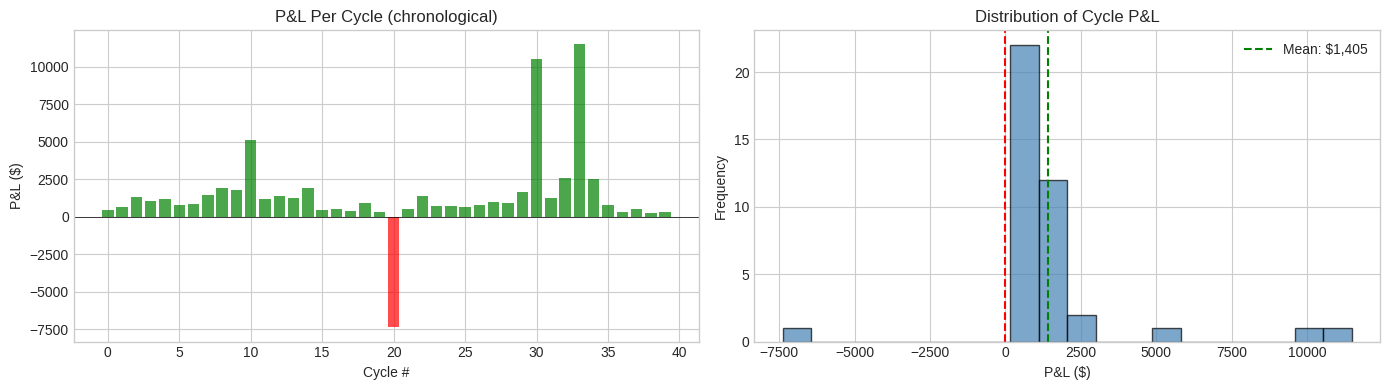

In [145]:
cycles_df = pd.DataFrame(trade_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['green' if x > 0 else 'red' for x in cycles_df['pnl']]
axes[0].bar(range(len(cycles_df)), cycles_df['pnl'], color=colors, alpha=0.7)
axes[0].set_title('P&L Per Cycle (chronological)')
axes[0].set_ylabel('P&L ($)')
axes[0].set_xlabel('Cycle #')
axes[0].axhline(0, color='black', linewidth=0.5)

axes[1].hist(cycles_df['pnl'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].axvline(cycles_df['pnl'].mean(), color='green', linestyle='--',
                label=f'Mean: ${cycles_df["pnl"].mean():,.0f}')
axes[1].set_title('Distribution of Cycle P&L')
axes[1].set_xlabel('P&L ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

fig.tight_layout()
plt.show()

### 9e. Monthly Returns Heatmap

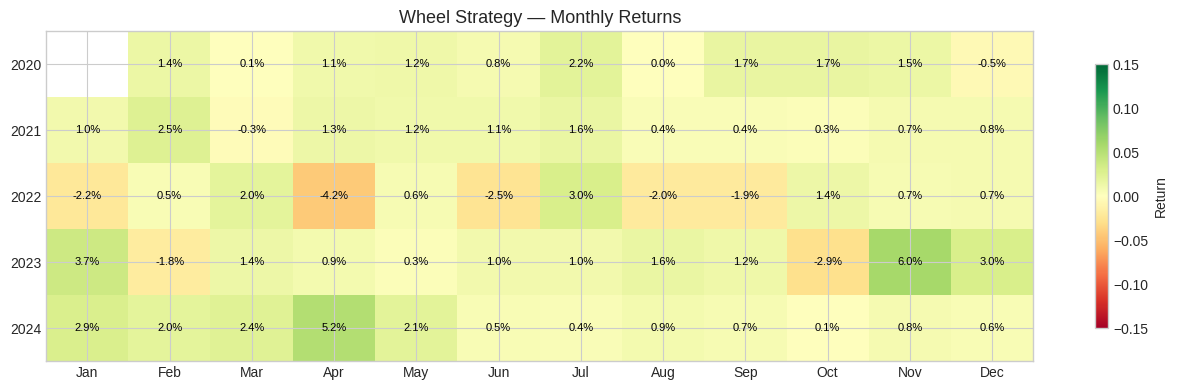

In [146]:
monthly = wheel_daily['total_value'].resample('ME').last().pct_change().dropna()

years = sorted(monthly.index.year.unique())
data = np.full((len(years), 12), np.nan)
for i, year in enumerate(years):
    for j in range(12):
        vals = monthly[(monthly.index.year == year) & (monthly.index.month == j + 1)]
        if not vals.empty:
            data[i, j] = vals.iloc[0]

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=-0.15, vmax=0.15)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years)
for i in range(len(years)):
    for j in range(12):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                    fontsize=8, color='black' if abs(val) < 0.1 else 'white')
ax.set_title('Wheel Strategy — Monthly Returns', fontsize=13)
fig.colorbar(im, ax=ax, label='Return', shrink=0.8)
fig.tight_layout()
plt.show()

### 9f. Cumulative Premium Income

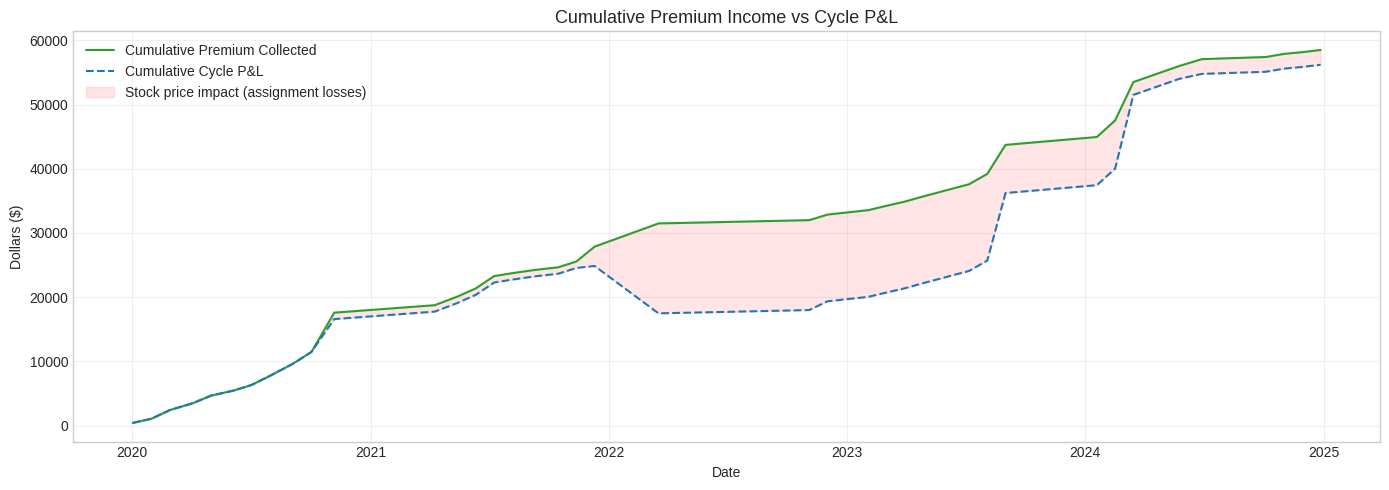

In [147]:
cycles_df = pd.DataFrame(trade_log)
cycles_df['cum_premium'] = cycles_df['total_premiums'].cumsum()
cycles_df['cum_pnl'] = cycles_df['pnl'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cycles_df['entry_date'], cycles_df['cum_premium'], label='Cumulative Premium Collected',
        linewidth=1.5, color='tab:green')
ax.plot(cycles_df['entry_date'], cycles_df['cum_pnl'], label='Cumulative Cycle P&L',
        linewidth=1.5, color='tab:blue', linestyle='--')
ax.fill_between(cycles_df['entry_date'], cycles_df['cum_premium'], cycles_df['cum_pnl'],
                alpha=0.1, color='red', label='Stock price impact (assignment losses)')
ax.set_title('Cumulative Premium Income vs Cycle P&L', fontsize=13)
ax.set_ylabel('Dollars ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 10. Summary

**Key takeaways:**

- The Wheel strategy generates consistent premium income (~97.5% win rate) with much lower volatility and drawdown
- However, it dramatically underperforms buy-and-hold on NVDA — covered calls cap the upside during explosive rallies
- The strategy works best on range-bound or moderately bullish stocks — NVDA's ~30x gain over 2020–2024 is the worst-case scenario for writing covered calls
- Max drawdown is significantly better: ~11% vs ~66% for buy-and-hold